## Lab-6: Distance-Based Classification and K-Nearest Neighbors

In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

np.random.seed(42)
n1 = 100
n2 = 100

mean1 = np.array([-1.5, -1])
mean2 = np.array([1.5, 1])
mat_eye = np.eye(2)

x1 = np.random.multivariate_normal(mean1, mat_eye, n1)
x2 = np.random.multivariate_normal(mean2, mat_eye, n2)

y1 = np.zeros(n1)
y2 = np.ones(n2)
X = np.vstack((x1, x2))
y = np.concatenate((y1, y2))
print(X)
print(f"Tracking - X shape: {X.shape}, y shape: {y.shape}")

[[-1.00328585e+00 -1.13826430e+00]
 [-8.52311462e-01  5.23029856e-01]
 [-1.73415337e+00 -1.23413696e+00]
 [ 7.92128155e-02 -2.32565271e-01]
 [-1.96947439e+00 -4.57439956e-01]
 [-1.96341769e+00 -1.46572975e+00]
 [-1.25803773e+00 -2.91328024e+00]
 [-3.22491783e+00 -1.56228753e+00]
 [-2.51283112e+00 -6.85752667e-01]
 [-2.40802408e+00 -2.41230370e+00]
 [-3.43512311e-02 -1.22577630e+00]
 [-1.43247180e+00 -2.42474819e+00]
 [-2.04438272e+00 -8.89077410e-01]
 [-2.65099358e+00 -6.24301982e-01]
 [-2.10063869e+00 -1.29169375e+00]
 [-2.10170661e+00  8.52278185e-01]
 [-1.51349722e+00 -2.05771093e+00]
 [-6.77455088e-01 -2.22084365e+00]
 [-1.29113640e+00 -2.95967012e+00]
 [-2.82818605e+00 -8.03138764e-01]
 [-7.61533420e-01 -8.28631719e-01]
 [-1.61564828e+00 -1.30110370e+00]
 [-2.97852199e+00 -1.71984421e+00]
 [-1.96063877e+00  5.71222262e-02]
 [-1.15638171e+00 -2.76304016e+00]
 [-1.17591603e+00 -1.38508228e+00]
 [-2.17692200e+00 -3.88323711e-01]
 [-4.69000478e-01 -6.87198809e-02]
 [-2.33921752e+00 -1

In [67]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

print(f"Tracking - x_train shape: {x_train.shape}")
print(f"Tracking - x_test shape: {x_test.shape}")
print(f"Tracking - y_train shape: {y_train.shape}")
print(f"Tracking - y_test shape: {y_test.shape}")

Tracking - x_train shape: (140, 2)
Tracking - x_test shape: (60, 2)
Tracking - y_train shape: (140,)
Tracking - y_test shape: (60,)


In [68]:
mean1_est = np.mean(x_train[y_train == 0], axis=0)
mean2_est = np.mean(x_train[y_train == 1], axis=0)

print(f"Tracking - Estimated Mean 1: {mean1_est}")
print(f"Tracking - Estimated Mean 2: {mean2_est}")

Tracking - Estimated Mean 1: [-1.54734039 -0.93615747]
Tracking - Estimated Mean 2: [1.61918651 1.01275567]


In [69]:
def euclidean_distance(x, mu):
    return np.sqrt(np.sum((x - mu)**2))

y_pred = []

for point in x_test:
    dist_to_mean1 = euclidean_distance(point, mean1_est)
    dist_to_mean2 = euclidean_distance(point, mean2_est)
    
    # Assign to class with minimum distance
    if dist_to_mean1 < dist_to_mean2:
        y_pred.append(0)
    else:
        y_pred.append(1)

y_pred = np.array(y_pred)

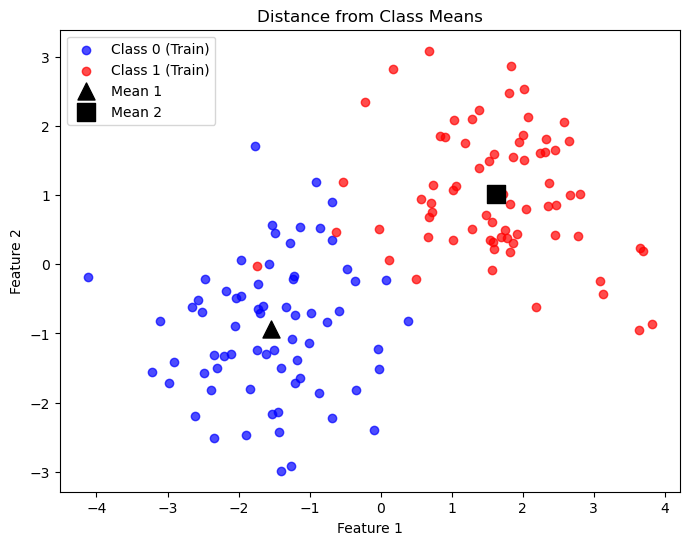

In [70]:
plt.figure(figsize=(8, 6))

# Plot training points with muted, sober colors
plt.scatter(x_train[y_train == 0][:, 0], x_train[y_train == 0][:, 1], 
            color='blue', label='Class 0 (Train)', alpha=0.7)
plt.scatter(x_train[y_train == 1][:, 0], x_train[y_train == 1][:, 1], 
            color='red', label='Class 1 (Train)', alpha=0.7)

plt.scatter(mean1_est[0], mean1_est[1], 
            color='black', marker='^', s=150, label='Mean 1')
plt.scatter(mean2_est[0], mean2_est[1], 
            color='black', marker='s', s=150, label='Mean 2')

plt.title('Distance from Class Means')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()

plt.show()

## Task 2: K-Nearest Neighbors Classification

K-NN Classification Accuracies:
K =  1 | Accuracy = 98.33%
K =  3 | Accuracy = 98.33%
K =  5 | Accuracy = 98.33%
K = 11 | Accuracy = 98.33%
K = 21 | Accuracy = 96.67%


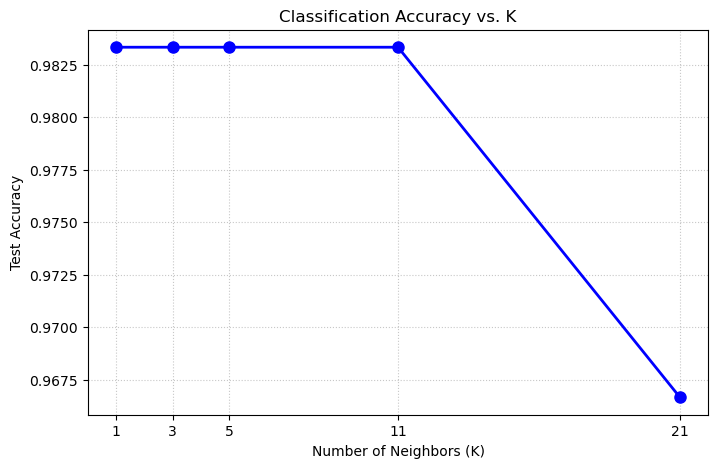

In [71]:
def knn_predict(X_train, y_train, X_test, k):
    y_pred = []
    for test_point in X_test:
        distances = [euclidean_distance(test_point, x_train_pt) for x_train_pt in X_train]
        k_indices = np.argsort(distances)[:k]
        k_nearest_labels = [y_train[i] for i in k_indices]
        majority_vote = max(set(k_nearest_labels), key=k_nearest_labels.count)
        y_pred.append(majority_vote)
    return np.array(y_pred)

k_values = [1, 3, 5, 11, 21]
accuracies = []

print("K-NN Classification Accuracies:")
for k in k_values:
    preds = knn_predict(x_train, y_train, x_test, k)
    acc = np.mean(preds == y_test)
    accuracies.append(acc)
    print(f"K = {k:2d} | Accuracy = {acc * 100:.2f}%")

plt.figure(figsize=(8, 5))
plt.plot(k_values, accuracies, marker='o', linestyle='-', color='b', linewidth=2, markersize=8)
plt.title('Classification Accuracy vs. K')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Test Accuracy')
plt.xticks(k_values)
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

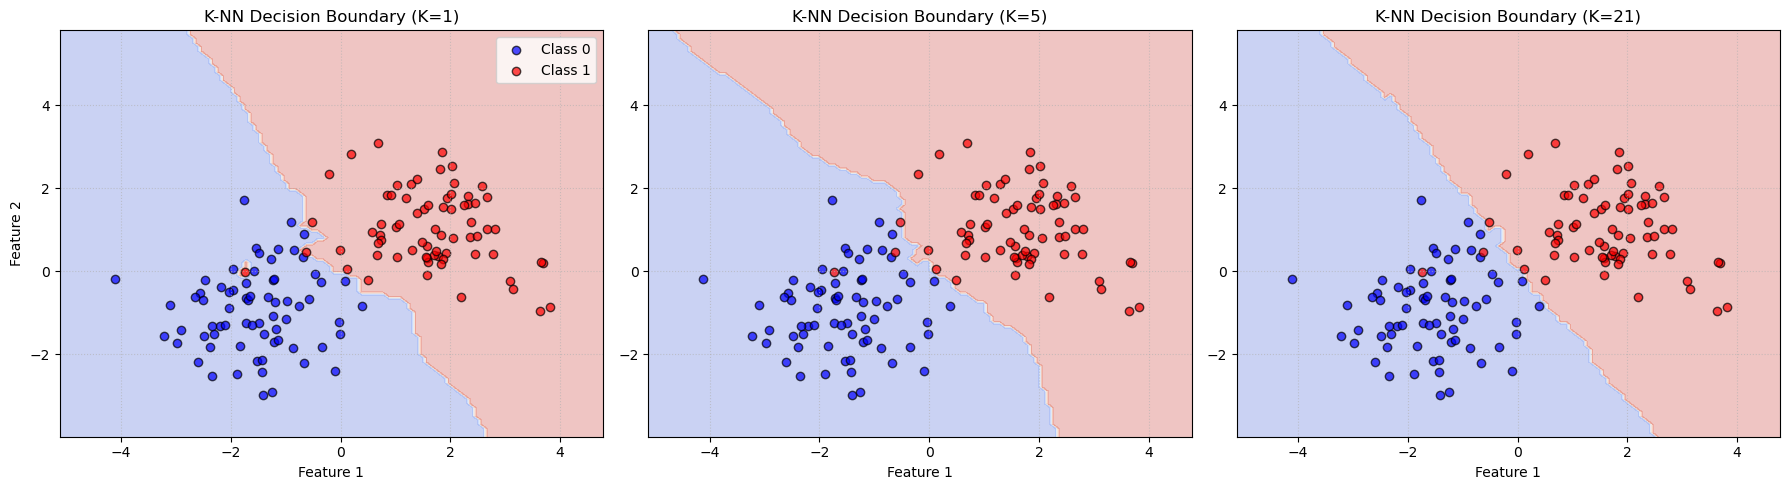

In [78]:
k_boundary_values = [1, 5, 21]

plt.figure(figsize=(18, 5))

x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))
mesh_points = np.c_[xx.ravel(), yy.ravel()]

for i, k in enumerate(k_boundary_values, 1):
    plt.subplot(1, 3, i)
    
    Z = knn_predict(x_train, y_train, mesh_points, k)
    Z = Z.reshape(xx.shape)
    
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
    plt.scatter(x_train[y_train == 0][:, 0], x_train[y_train == 0][:, 1], 
                color='blue', label='Class 0', alpha=0.7, edgecolors='k')
    plt.scatter(x_train[y_train == 1][:, 0], x_train[y_train == 1][:, 1], 
                color='red', label='Class 1', alpha=0.7, edgecolors='k')
    
    plt.title(f'K-NN Decision Boundary (K={k})')
    plt.xlabel('Feature 1')
    if i == 1:
        plt.ylabel('Feature 2')
        plt.legend()
        
    plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()